In [1]:
import torch 
import numpy as np 
from models import ToySuperpositionAE, Faithful_SAE
from train_sae import Config
from pathlib import Path
import yaml
from dataclasses import dataclass, field, asdict
from typing import Any
from dataclasses import fields

from load_run import load_run

/usr/local/lib/python3.8/dist-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TypeError: unsupported operand type(s) for |: 'type' and 'NoneType'

In [ ]:
cfg, autoencoder, faith_ae = load_run('runs/20250710-221658_in5_c5_lat2_seed1483060847', device='cuda') 

In [ ]:
autoencoder

In [2]:
faith_ae

NameError: name 'faith_ae' is not defined

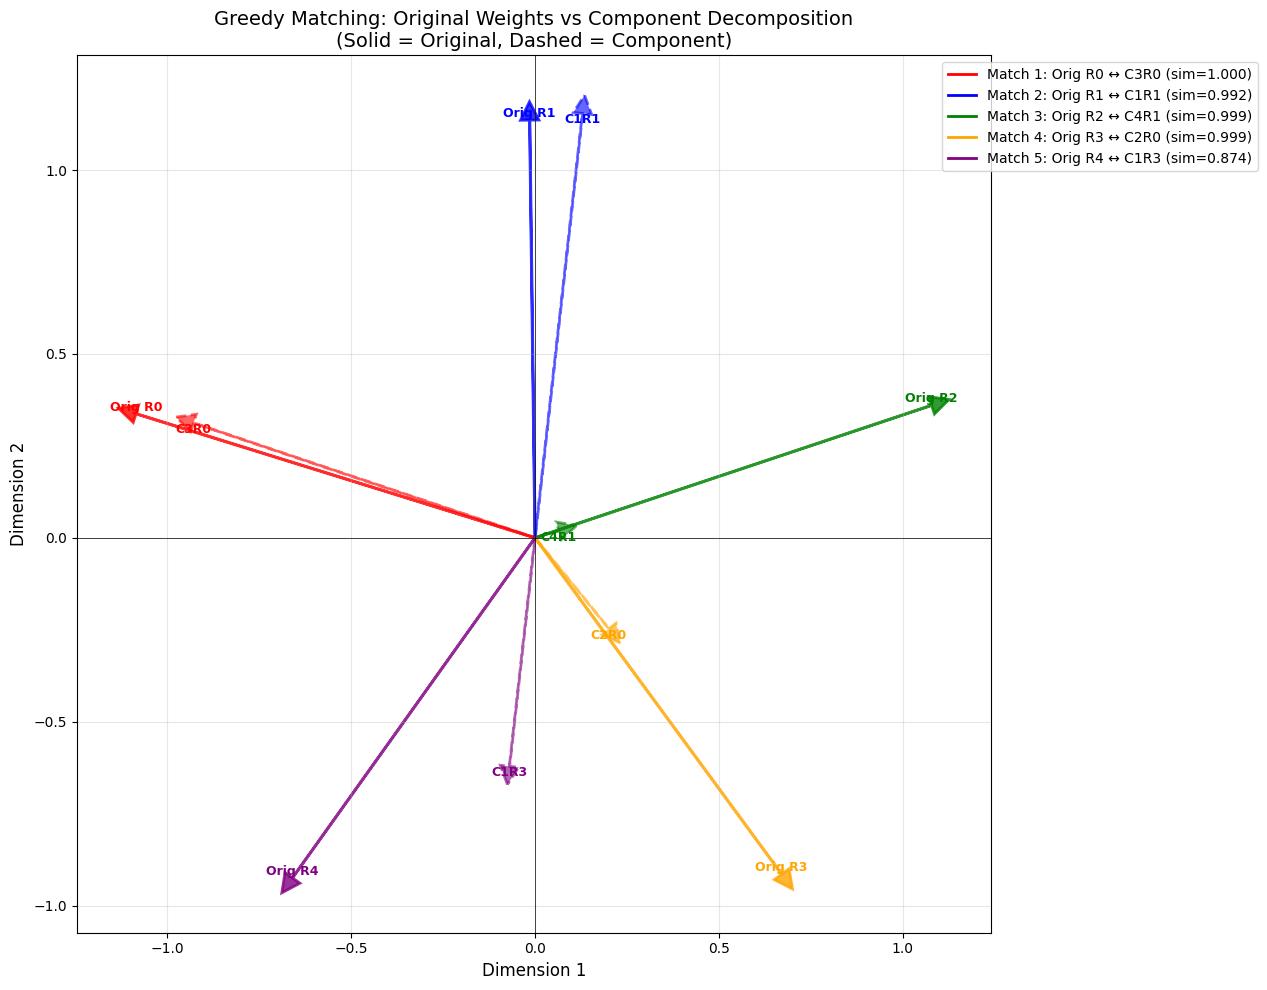

Matching Results:
Match 1:
  Original Row 0: [-1.0852726   0.33747795]
  Component 3, Row 0: [-0.9288682   0.31236297]
  Cosine Similarity: 0.9997

Match 2:
  Original Row 1: [-0.01449186  1.1359334 ]
  Component 1, Row 1: [0.12913492 1.154014  ]
  Cosine Similarity: 0.9923

Match 3:
  Original Row 2: [1.0783329 0.3602857]
  Component 4, Row 1: [0.06468832 0.01907462]
  Cosine Similarity: 0.9994

Match 4:
  Original Row 3: [ 0.6707111 -0.9148321]
  Component 2, Row 0: [ 0.20104532 -0.24750182]
  Cosine Similarity: 0.9988

Match 5:
  Original Row 4: [-0.65965533 -0.92481136]
  Component 1, Row 3: [-0.06954247 -0.62146604]
  Cosine Similarity: 0.8736



In [10]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def greedy_match_and_plot(orig_weights, components):    
    orig_weights_np = orig_weights.detach().cpu().numpy()
    components_np = components.detach().cpu().numpy()
    
    num_components, num_rows, num_features = components_np.shape
    
    all_component_rows = []
    component_indices = [] 
    
    for c_idx in range(num_components):
        for r_idx in range(num_rows):
            all_component_rows.append(components_np[c_idx, r_idx])
            component_indices.append((c_idx, r_idx))
    
    all_component_rows = np.array(all_component_rows)
    
    matches = []
    used_component_indices = set()
    
    for orig_row_idx in range(orig_weights_np.shape[0]):
        orig_row = orig_weights_np[orig_row_idx].reshape(1, -1)
        
        best_similarity = -1
        best_match_idx = -1
        
        for comp_row_idx, comp_row in enumerate(all_component_rows):
            if comp_row_idx in used_component_indices:
                continue
                
            comp_row_reshaped = comp_row.reshape(1, -1)
            
            similarity = cosine_similarity(orig_row, comp_row_reshaped)[0, 0]
            
            if similarity > best_similarity:
                best_similarity = similarity
                best_match_idx = comp_row_idx
        
        if best_match_idx != -1:
            matches.append({
                'orig_row_idx': orig_row_idx,
                'comp_row_idx': best_match_idx,
                'component_idx': component_indices[best_match_idx][0],
                'component_row_idx': component_indices[best_match_idx][1],
                'similarity': best_similarity,
                'orig_vector': orig_weights_np[orig_row_idx],
                'comp_vector': all_component_rows[best_match_idx]
            })
            used_component_indices.add(best_match_idx)
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
    
    for i, match in enumerate(matches):
        color = colors[i % len(colors)]
        
        orig_vec = match['orig_vector']
        ax.arrow(0, 0, orig_vec[0], orig_vec[1], 
                head_width=0.05, head_length=0.05, 
                fc=color, ec=color, linewidth=2, alpha=0.8)
        
        comp_vec = match['comp_vector']
        ax.arrow(0, 0, comp_vec[0], comp_vec[1], 
                head_width=0.05, head_length=0.05, 
                fc=color, ec=color, linewidth=2, alpha=0.6, linestyle='--')
        
        ax.text(orig_vec[0], orig_vec[1], 
               f'Orig R{match["orig_row_idx"]}', 
               fontsize=9, ha='center', va='bottom', color=color, weight='bold')
        
        ax.text(comp_vec[0], comp_vec[1], 
               f'C{match["component_idx"]}R{match["component_row_idx"]}', 
               fontsize=9, ha='center', va='top', color=color, weight='bold')
    
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
    
    ax.set_xlabel('Dimension 1', fontsize=12)
    ax.set_ylabel('Dimension 2', fontsize=12)
    ax.set_title('Greedy Matching: Original Weights vs Component Decomposition\n(Solid = Original, Dashed = Component)', fontsize=14)
    
    legend_elements = []
    for i, match in enumerate(matches):
        color = colors[i % len(colors)]
        legend_elements.append(plt.Line2D([0], [0], color=color, lw=2, 
                                        label=f'Match {i+1}: Orig R{match["orig_row_idx"]} ↔ C{match["component_idx"]}R{match["component_row_idx"]} (sim={match["similarity"]:.3f})'))
    
    ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.3, 1))
    
    plt.tight_layout()
    plt.show()
    
    print("Matching Results:")
    print("=" * 60)
    for i, match in enumerate(matches):
        print(f"Match {i+1}:")
        print(f"  Original Row {match['orig_row_idx']}: {match['orig_vector']}")
        print(f"  Component {match['component_idx']}, Row {match['component_row_idx']}: {match['comp_vector']}")
        print(f"  Cosine Similarity: {match['similarity']:.4f}")
        print()
    
    return matches


orig_weights = autoencoder.encoder_weights.detach().cpu()

components = faith_ae.components().detach().cpu()
matches = greedy_match_and_plot(orig_weights, components)